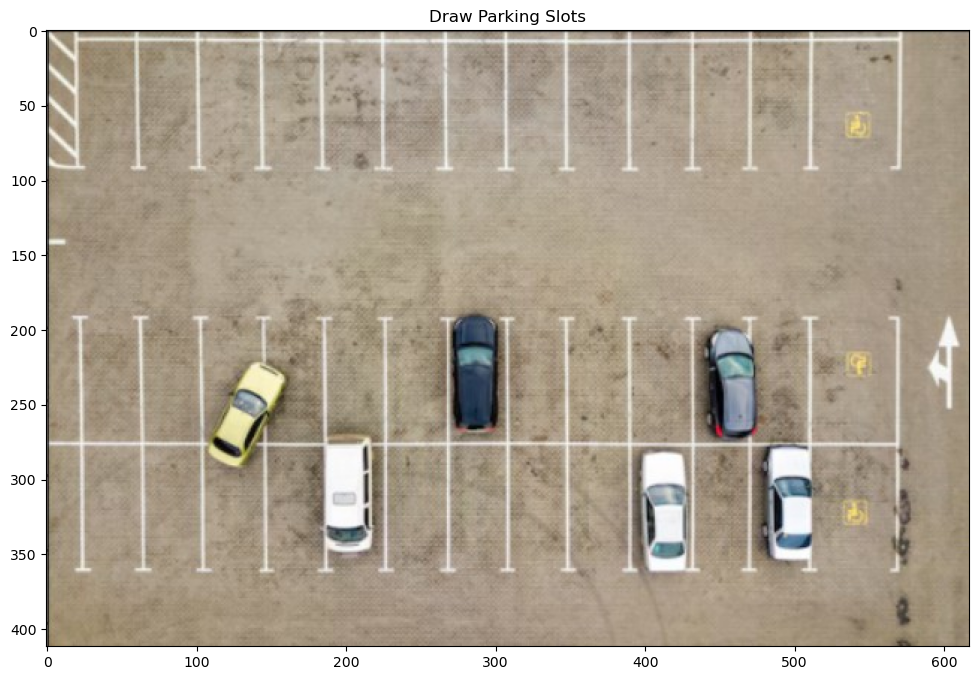


All Parking Slots:
[]


In [1]:
import cv2
import matplotlib.pyplot as plt

# =========================
# LOAD IMAGE
# =========================
image_path = r"C:\Users\abdiz\Desktop\test.jpg"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Copy for drawing
display_img = img.copy()

# =========================
# VARIABLES
# =========================
start_point = None
drawing = False

# Store parking slots
parking_slots = []

# =========================
# CREATE FIGURE
# =========================
fig, ax = plt.subplots(figsize=(12,8))
image_plot = ax.imshow(display_img)

# =========================
# MOUSE PRESS
# =========================
def on_press(event):
    global start_point, drawing

    if event.xdata is None or event.ydata is None:
        return

    start_point = (int(event.xdata), int(event.ydata))
    drawing = True

# =========================
# MOUSE MOVE
# =========================
def on_move(event):
    global display_img

    if not drawing:
        return

    if event.xdata is None or event.ydata is None:
        return

    temp_img = img.copy()

    x1, y1 = start_point
    x2, y2 = int(event.xdata), int(event.ydata)

    cv2.rectangle(temp_img, (x1, y1), (x2, y2), (0,255,0), 2)

    image_plot.set_data(temp_img)
    fig.canvas.draw_idle()

# =========================
# MOUSE RELEASE
# =========================
def on_release(event):
    global drawing, display_img

    if event.xdata is None or event.ydata is None:
        return

    drawing = False

    x1, y1 = start_point
    x2, y2 = int(event.xdata), int(event.ydata)

    # Save slot coordinates
    parking_slots.append((x1, y1, x2-x1, y2-y1))

    # Draw permanent rectangle
    cv2.rectangle(display_img, (x1, y1), (x2, y2), (0,255,0), 2)

    image_plot.set_data(display_img)
    fig.canvas.draw_idle()

    print(f"Slot Added: ({x1}, {y1}, {x2-x1}, {y2-y1})")

# =========================
# CONNECT EVENTS
# =========================
fig.canvas.mpl_connect('button_press_event', on_press)
fig.canvas.mpl_connect('motion_notify_event', on_move)
fig.canvas.mpl_connect('button_release_event', on_release)

plt.title("Draw Parking Slots")
plt.axis("on")
plt.show()

# =========================
# PRINT ALL SLOTS
# =========================
print("\nAll Parking Slots:")
print(parking_slots)


Loading images from: C:\Users\abdiz\Downloads\train\empty

Loading images from: C:\Users\abdiz\Downloads\train\occupied

Dataset Loaded Successfully!
Images Shape: (1726, 48, 48)
Labels Shape: (1726,)


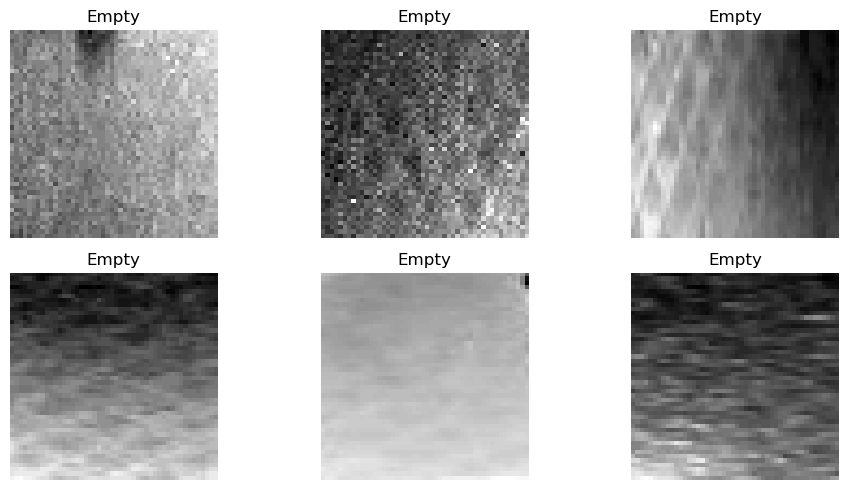


Training Shape: (1380, 48, 48, 1)
Testing Shape: (346, 48, 48, 1)


C:\Users\abdiz\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 46, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 44, 44, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 22, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 20, 20, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 20, 20, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 9, 9, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 9, 9, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5184)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         663,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 729,314 (2.78 MB)

 Trainable params: 729,122 (2.78 MB)

 Non-trainable params: 192 (768.00 B)

C:\Users\abdiz\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 255ms/step - accuracy: 0.8080 - loss: 1.0459 - val_accuracy: 0.7572 - val_loss: 0.6434
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.9217 - loss: 0.1704 - val_accuracy: 0.6243 - val_loss: 0.6357
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.9283 - loss: 0.1611 - val_accuracy: 0.5376 - val_loss: 0.7796
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.9406 - loss: 0.1348 - val_accuracy: 0.5260 - val_loss: 0.9977
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.9464 - loss: 0.1081 - val_accuracy: 0.5260 - val_loss: 1.7022
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.9500 - loss: 0.1130 - val_accuracy: 0.5260 - val_loss: 1.5820
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.9449 - loss: 0.1193 - val_accuracy: 0.5260 - val_loss: 1.7876
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.9435 - loss: 0.1131 - val_accuracy: 0

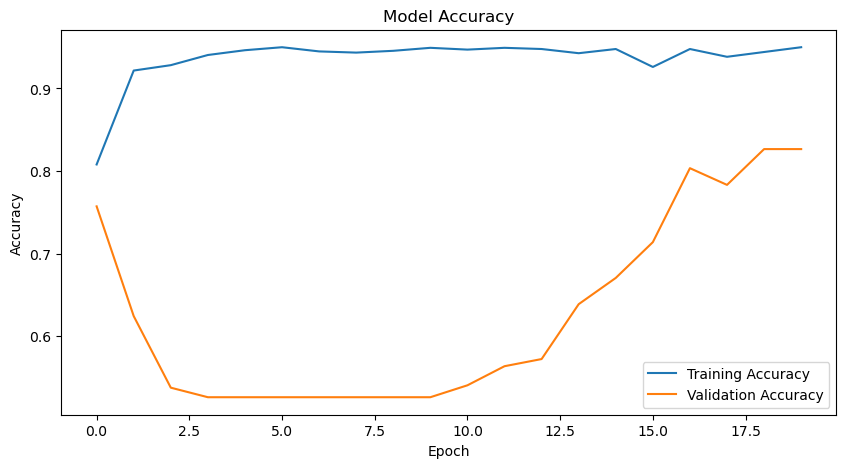


✅ Model saved successfully!


In [2]:
# =========================================================
# SMART PARKING SYSTEM - JUPYTER NOTEBOOK VERSION
# =========================================================

# =========================
# IMPORT LIBRARIES
# =========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Enable matplotlib inside Jupyter
%matplotlib inline

# =========================================================
# DATASET PATHS
# =========================================================

empty_path = r"C:\Users\abdiz\Downloads\train\empty"
occupied_path = r"C:\Users\abdiz\Downloads\train\occupied"

training_data = [
    empty_path,
    occupied_path
]

# =========================================================
# SETTINGS
# =========================================================

IMG_SIZE = 48

# =========================================================
# LOAD IMAGES FUNCTION
# =========================================================

def load_images(training_data):

    images = []
    labels = []

    for i, folder in enumerate(training_data):

        print(f"\nLoading images from: {folder}")

        for filename in os.listdir(folder):

            path = os.path.join(folder, filename)

            try:
                # Read grayscale image
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

                # Skip bad images
                if img is None:
                    continue

                # Resize image
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                images.append(img)
                labels.append(i)

            except Exception as e:
                print(f"Error loading {path}: {e}")

    return np.array(images), np.array(labels)

# =========================================================
# LOAD DATASET
# =========================================================

images, labels = load_images(training_data)

print("\nDataset Loaded Successfully!")
print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

# =========================================================
# DISPLAY SAMPLE IMAGES
# =========================================================

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i], cmap='gray')

    if labels[i] == 0:
        plt.title("Empty")
    else:
        plt.title("Occupied")

    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# =========================================================
# PREPROCESSING
# =========================================================

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype('float32') / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =========================================================
# DATA AUGMENTATION
# =========================================================

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

# =========================================================
# BUILD CNN MODEL
# =========================================================

model = Sequential()

# -------------------------
# FIRST CONV BLOCK
# -------------------------
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(IMG_SIZE, IMG_SIZE, 1)
))

model.add(BatchNormalization())

model.add(Conv2D(32, (3,3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

# -------------------------
# SECOND CONV BLOCK
# -------------------------
model.add(Conv2D(64, (3,3), activation='relu'))

model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

# -------------------------
# FULLY CONNECTED LAYERS
# -------------------------
model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# OUTPUT LAYER
model.add(Dense(2, activation='softmax'))

# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# MODEL SUMMARY
# =========================================================

model.summary()

# =========================================================
# TRAIN MODEL
# =========================================================

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

# =========================================================
# EVALUATE MODEL
# =========================================================

loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# =========================================================
# PLOT ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# =========================================================
# SAVE MODEL
# =========================================================

model.save("smart_parking_model.h5")

print("\n✅ Model saved successfully!")

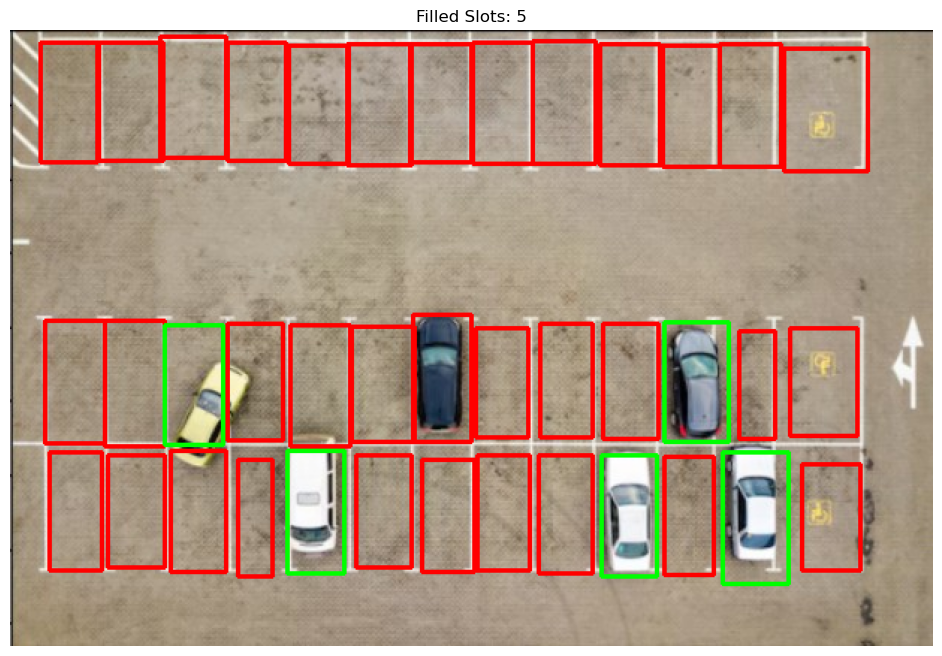

Total Filled Slots: 5


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

# =========================
# LOAD MODEL
# =========================
model = load_model("smart_parking_model.h5")
model.compile(loss="categorical_crossentropy", optimizer="adam")

# =========================
# PARKING SLOT COORDINATES
# =========================
coordinates = [
    [(20, 8), (58, 88)], [(59, 8), (102, 87)], [(100, 4), (144, 85)],
    [(145, 8), (184, 87)], [(186, 10), (226, 89)], [(225, 9), (268, 90)],
    [(267, 9), (308, 88)], [(309, 8), (349, 89)], [(349, 7), (391, 89)],
    [(394, 9), (434, 90)], [(436, 10), (474, 91)], [(474, 9), (515, 91)],
    [(517, 12), (573, 94)], [(23, 194), (63, 276)], [(63, 194), (103, 278)],
    [(103, 197), (142, 277)], [(145, 196), (182, 274)], [(187, 197), (227, 278)],
    [(228, 198), (270, 275)], [(269, 190), (308, 275)], [(311, 199), (346, 272)],
    [(354, 196), (389, 272)], [(396, 196), (433, 273)], [(437, 195), (480, 275)],
    [(487, 201), (511, 273)], [(521, 199), (566, 271)], [(26, 282), (61, 361)],
    [(65, 284), (103, 359)], [(107, 281), (144, 362)], [(152, 287), (175, 365)],
    [(185, 281), (223, 363)], [(231, 284), (268, 359)], [(275, 287), (310, 362)],
    [(312, 284), (347, 361)], [(353, 284), (389, 363)], [(395, 284), (432, 365)],
    [(437, 285), (470, 364)], [(476, 282), (520, 370)], [(529, 290), (568, 361)]
]

# =========================
# LOAD IMAGE
# =========================
img_path = r"C:\Users\abdiz\Desktop\test.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

output = img.copy()

# =========================
# FUNCTION
# =========================
def is_empty_slot(image, spot):

    x1, y1 = spot[0]
    x2, y2 = spot[1]

    roi = image[y1:y2, x1:x2]

    if roi.size == 0:
        return False

    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (48, 48))

    gray = gray.astype("float32") / 255.0
    gray = np.expand_dims(gray, axis=(0, -1))

    pred = model.predict(gray, verbose=0)

    return pred[0][0] < 0.5  # empty = True

# =========================
# DETECTION LOOP
# =========================
empty_count = 0

for spot in coordinates:

    x1, y1 = spot[0]
    x2, y2 = spot[1]

    if is_empty_slot(output, spot):
        color = (0, 255, 0)
        empty_count += 1
    else:
        color = (255, 0, 0)

    cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

# =========================
# SHOW RESULT
# =========================
plt.figure(figsize=(12, 8))
plt.imshow(output)
plt.axis("off")
plt.title(f"Filled Slots: {empty_count}")
plt.show()

print("Total Filled Slots:", empty_count)